In [70]:
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.datasets import load_iris
# import graphviz 
import pandas as pd
import numpy as np
import seaborn as sns

# Entrenamiento de SVM

In [19]:
iris = load_iris()

In [21]:
x_train,x_test,y_train,y_test=train_test_split(iris.data, iris.target, test_size=0.2, random_state=2023)

In [22]:
clf = svm.SVC() # kernel default 'rbf'
clf.fit(x_train, y_train)

SVC()

In [23]:
clf.score(x_test, y_test)

1.0

In [ ]:
# Matriz de confusion
predictions = clf.predict(x_test)
cm = confusion_matrix(y_test, predictions )
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [75]:
iris_dataframe = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])

In [77]:
iris_dataframe

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


# Correlacion entre variables

<Axes: >

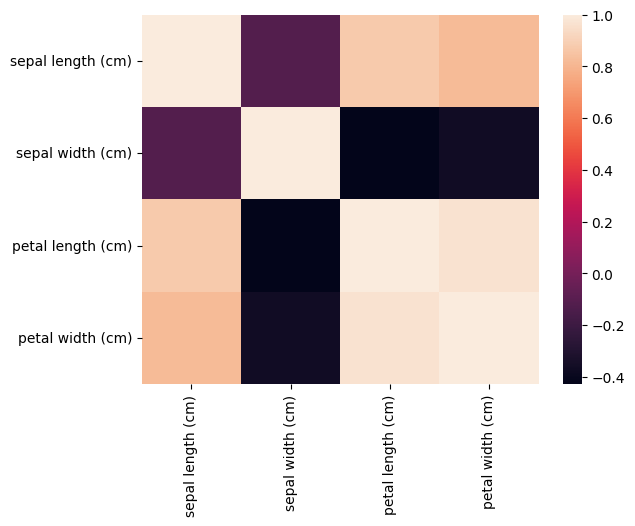

In [92]:
sns.heatmap(iris_dataframe.iloc[:,:4].corr())

# Entrenamiento con solo 2 caracteristicas (no es posible graficar 4 dimensiones)

In [97]:
X = iris.data[:, [1,2]] # columas 1 y 2 (0,1,2,3) -> (sepal length (cm), sepal width (cm), petal length (cm), petal width (cm))
y = iris.target

In [98]:
clf = svm.SVC(kernel='rbf')
clf.fit(X, y)

SVC()

In [102]:
clf.score(X, y)

0.9533333333333334

In [99]:
X0, X1 = X[:, 0], X[:, 1] # una columna para x otra para y en el plano

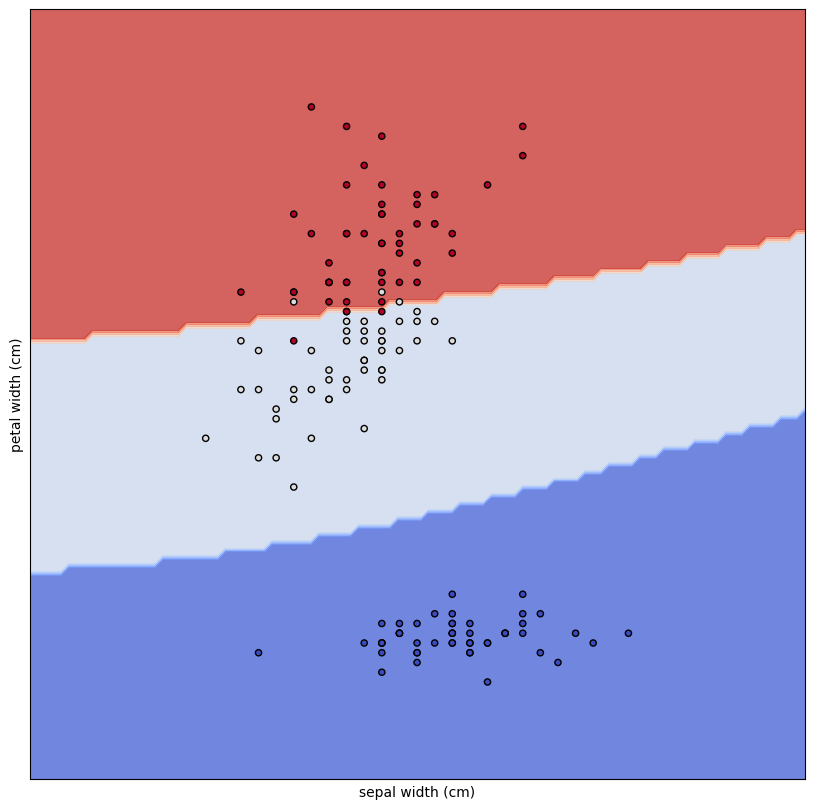

In [100]:
figure = plt.figure(figsize=(10,10))
axes = figure.add_subplot(111)
disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,
        ax=axes,
        xlabel=iris.feature_names[1],
        ylabel=iris.feature_names[3],
    )
axes.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
axes.set_xticks(())
axes.set_yticks(())

plt.show()

In [62]:
clf = svm.SVC(kernel='poly', degree=3) # Con kernel poly
clf.fit(X, y)

SVC(kernel='poly')

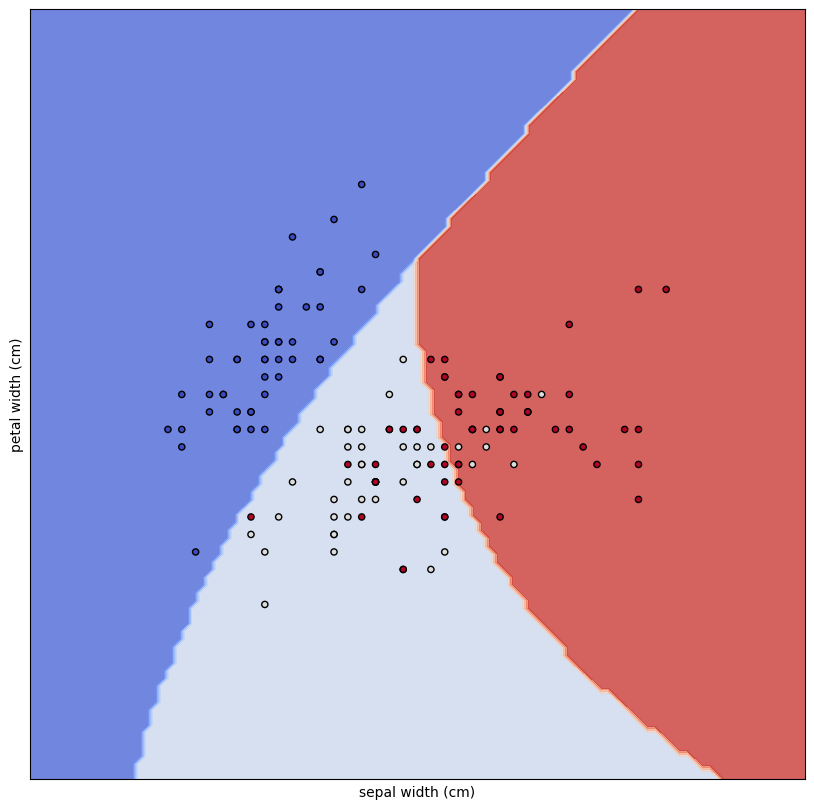

In [63]:
figure = plt.figure(figsize=(10,10))
axes = figure.add_subplot(111)
disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,
        ax=axes,
        xlabel=iris.feature_names[1],
        ylabel=iris.feature_names[3],
    )
axes.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
axes.set_xticks(())
axes.set_yticks(())

plt.show()

# Test con diferentes kernels y configuraciones

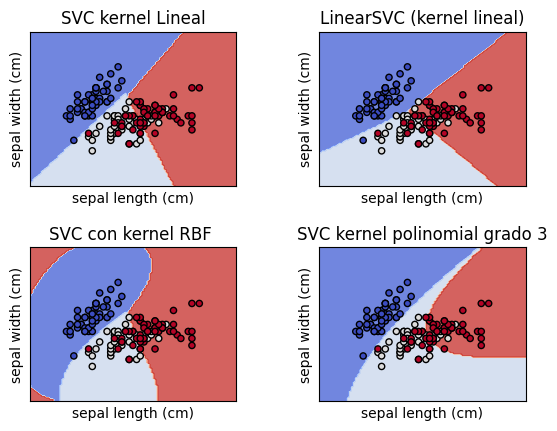

In [66]:
import matplotlib.pyplot as plt

from sklearn import datasets, svm
from sklearn.inspection import DecisionBoundaryDisplay

iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

C = 1.0
models = (
    svm.SVC(kernel="linear", C=C),
    svm.LinearSVC(C=C, max_iter=10000, dual="auto"),
    svm.SVC(kernel="rbf", gamma=0.7, C=C),
    svm.SVC(kernel="poly", degree=3, gamma="auto", C=C),
)
models = (clf.fit(X, y) for clf in models)


titles = (
    "SVC kernel Lineal",
    "LinearSVC (kernel lineal)",
    "SVC con kernel RBF ",
    "SVC kernel polinomial grado 3",
)

fig, sub = plt.subplots(2, 2)
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X[:, 0], X[:, 1]

for clf, title, ax in zip(models, titles, sub.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,
        ax=ax,
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
    )
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

plt.show()